In [1]:
#EDA - Se ha realizado ya en el proyecto 03 de Analyst en el cual se hizo todo el proceso de EDA y limpiar los datos
#Del q se obtuvo 'telco_churn_clean.csv'

In [1]:
# Manipulación de data.frames
import pandas as pd
import numpy as np

# Librerías para Gráficos
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Librerías para datos de entrenamiento y prueba
from sklearn.model_selection    import train_test_split
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Para preprocesamiento
from sklearn.preprocessing      import StandardScaler, MinMaxScaler
from sklearn.preprocessing      import LabelEncoder, OneHotEncoder
from sklearn.compose            import ColumnTransformer
from sklearn.pipeline           import Pipeline

# Para modelos de clasificación
from sklearn.neighbors          import KNeighborsClassifier
from sklearn.linear_model       import LogisticRegression
from sklearn.tree               import DecisionTreeClassifier
from sklearn.svm                import SVC
from sklearn.ensemble           import RandomForestClassifier
from xgboost import XGBClassifier

# Métricas de evaluación
from sklearn.metrics            import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics            import accuracy_score, precision_score, recall_score, f1_score
from imblearn.metrics           import specificity_score

# para hacer la curva ROC
from sklearn.metrics            import roc_auc_score
from sklearn.metrics            import roc_curve

# Optimización de hiperparámetros
from sklearn.model_selection    import GridSearchCV

import time

# Guardar modelos
import joblib
import os

# Para ignorar los warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
telco_churn_df = pd.read_csv('telco_churn_clean.csv')
telco_churn_df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,female,False,yes,no,1,no,no phone service,dsl,no,...,no,no,no,no,month-to-month,yes,electronic check,29.85,29.85,no
1,5575-GNVDE,male,False,no,no,34,yes,no,dsl,yes,...,yes,no,no,no,one year,no,mailed check,56.95,1889.50,no
2,3668-QPYBK,male,False,no,no,2,yes,no,dsl,yes,...,no,no,no,no,month-to-month,yes,mailed check,53.85,108.15,yes
3,7795-CFOCW,male,False,no,no,45,no,no phone service,dsl,yes,...,yes,yes,no,no,one year,no,bank transfer (automatic),42.30,1840.75,no
4,9237-HQITU,female,False,no,no,2,yes,no,fiber optic,no,...,no,no,no,no,month-to-month,yes,electronic check,70.70,151.65,yes


In [3]:
telco_churn_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   bool   
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
telco_churn_df.describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


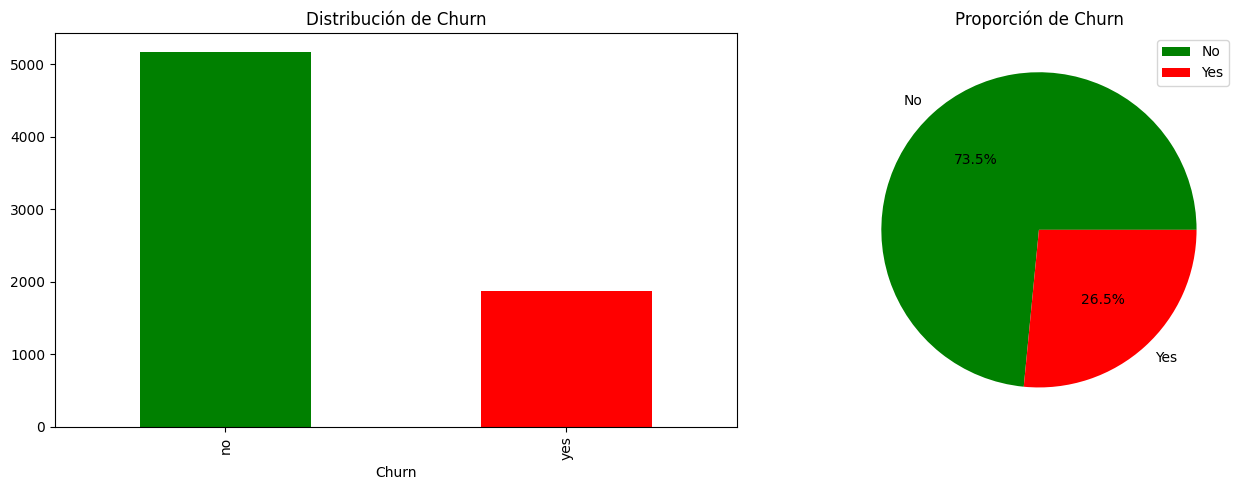

In [5]:
import matplotlib.pyplot as plt

# 1. Distribución de Churn
fig, axes = plt.subplots(1, 2, figsize=(14, 5)) # Changed to 1 row, 2 columns
# Countplot
telco_churn_df['Churn'].value_counts().plot(kind='bar', ax=axes[0], color=['green','red'])
axes[0].set_title('Distribución de Churn')
axes[0].set_xlabel('Churn')

# Pie chart
churn_counts = telco_churn_df['Churn'].value_counts()
churn_counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', colors= ['green', 'red'], labels=['No', 'Yes'], legend=True)
axes[1].set_title('Proporción de Churn')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

In [6]:
# 2. Churn por variables categóricas
categorical_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
                    'PhoneService', 'MultipleLines', 'InternetService',
                    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                    'TechSupport', 'StreamingTV', 'StreamingMovies',
                    'Contract', 'PaperlessBilling', 'PaymentMethod']

# Convert 'Churn' column to numeric (0 and 1) for mean calculation
telco_churn_df['Churn_numeric'] = telco_churn_df['Churn'].map({'yes': 1, 'no': 0})

churn_by_cat = {}
for col in categorical_cols:
    # Calculate mean of Churn_numeric instead of original Churn
    churn_by_cat[col] = telco_churn_df.groupby(col)['Churn_numeric'].mean()

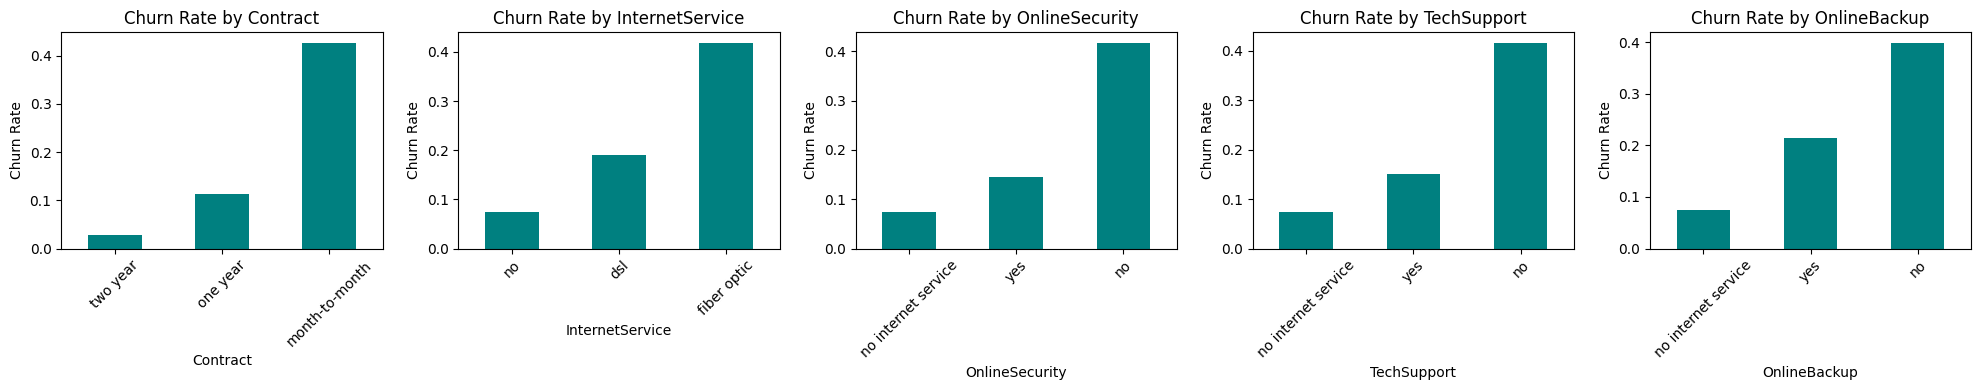

In [7]:
# Top 5 variables con mayor diferencia
top_cat = sorted(churn_by_cat.items(), key=lambda x: x[1].max() - x[1].min(), reverse=True)[:5]

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, (col, data) in enumerate(top_cat):
    data.sort_values().plot(kind='bar', ax=axes[i], color='teal')
    axes[i].set_title(f'Churn Rate by {col}')
    axes[i].set_ylabel('Churn Rate')
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

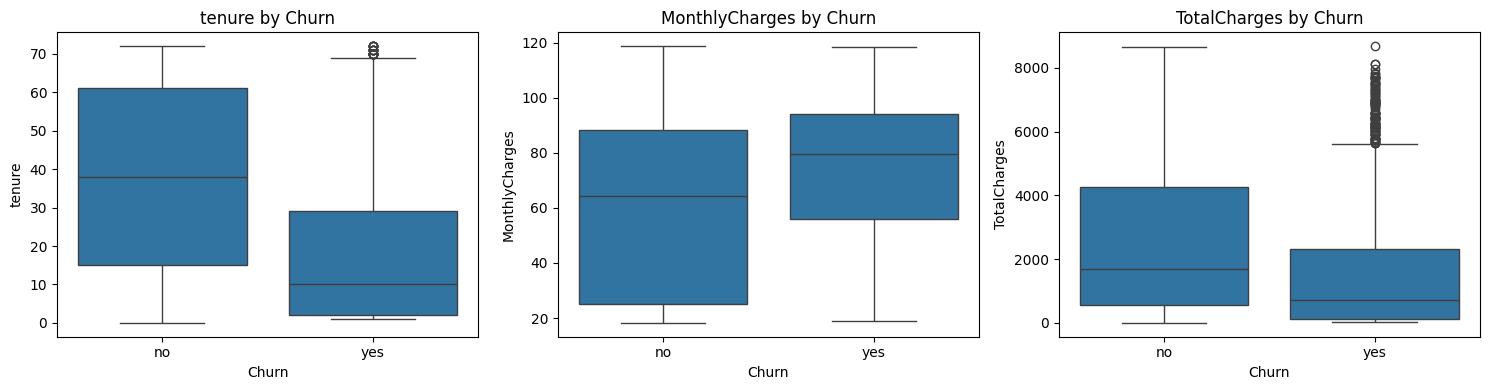

In [8]:
# 3. Variables numéricas
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(numeric_cols):
    sns.boxplot(x='Churn', y=col, data=telco_churn_df, ax=axes[i])
    axes[i].set_title(f'{col} by Churn')
plt.tight_layout()
plt.show()

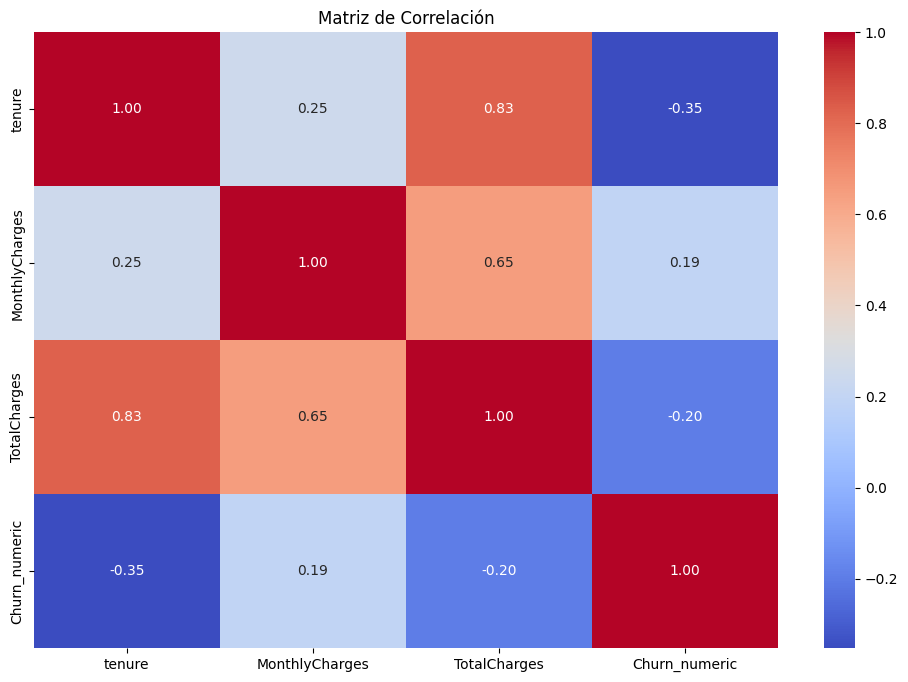

In [9]:
# 4. Matriz de correlación
plt.figure(figsize=(12, 8))
sns.heatmap(telco_churn_df[numeric_cols + ['Churn_numeric']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación')
plt.show()

In [ ]:
#FIN EDA, Sigue entrenamiento modelos

In [10]:
# veamos la variable churn (OBJETIVO)
telco_churn_df['Churn'].unique()

array(['no', 'yes'], dtype=object)

In [11]:
#Variable transformada en 1 y 0, 0 = No, 1 = Yes
telco_churn_df['Churn_numeric'].value_counts()

,count
Churn_numeric,
0,5174
1,1869


In [12]:
#DATOS DESBALANCEADOS

In [13]:
#Separamos las variables categóricas de las numéricas
#Transformamos bool a int, el SeniorCitizen de bool a int
telco_churn_df['SeniorCitizen'] = telco_churn_df['SeniorCitizen'].astype(int)
telco_churn_df.info()
telco_churn_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_numeric
0,7590-VHVEG,female,0,yes,no,1,no,no phone service,dsl,no,...,no,no,no,month-to-month,yes,electronic check,29.85,29.85,no,0
1,5575-GNVDE,male,0,no,no,34,yes,no,dsl,yes,...,no,no,no,one year,no,mailed check,56.95,1889.50,no,0
2,3668-QPYBK,male,0,no,no,2,yes,no,dsl,yes,...,no,no,no,month-to-month,yes,mailed check,53.85,108.15,yes,1
3,7795-CFOCW,male,0,no,no,45,no,no phone service,dsl,yes,...,yes,no,no,one year,no,bank transfer (automatic),42.30,1840.75,no,0
4,9237-HQITU,female,0,no,no,2,yes,no,fiber optic,no,...,no,no,no,month-to-month,yes,electronic check,70.70,151.65,yes,1


In [14]:
telco_churn_df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'Churn_numeric'],
      dtype='object')

In [15]:
# variables numéricas de predicción
variables_num = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']
variables_num

['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']

In [16]:
# variables categóricas de predicción
variables_cat = telco_churn_df.drop(['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn', 'Churn_numeric' ], axis = 1).columns
variables_cat

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

In [73]:
#Ahora aplicamos los modelos, paso a paso
#Definir variables
#Separar entrenamiento y prueba
#Escalar los datos para los modelos que necesiten datos escalados


In [17]:
# 1. Dividir en dos conjuntos
# las variables predictoras
X = telco_churn_df.drop(['Churn', 'Churn_numeric'], axis = 1)
# la variable objetivo
y = telco_churn_df['Churn_numeric']

# 2. conjunto de entrenamiento, validación y prueba, Datos desbalanciados
#1. PRIMERA DIVISIÓN: Train (60%) y Temp (40%)
X_train, X_temp, y_train, y_temp = train_test_split(
                                                    X,                          # variables predictoras
                                                    y,                          # variable de respuesta
                                                    stratify=y,                 # estratificamos con respecto a y
                                                    test_size=0.4,              # 20% para temp (que luego se divide en val y test)
                                                    random_state=42             # semilla para reproducibilidad
                                                )
#2. SEGUNDA DIVISIÓN: Temp → Validation (50%) y Test (50%)
X_val, X_test, y_val, y_test = train_test_split(
                                                X_temp,                     # datos temporales
                                                y_temp,                     # etiquetas temporales
                                                stratify=y_temp,            # estratificamos con respecto a y_temp
                                                test_size=0.5,              # 50% de Temp = 10% del total para Test
                                                random_state=42             # semilla para reproducibilidad
                                              )



# 3. Definimos el preprocesador de escalamiento
preprocessor_1 = ColumnTransformer(transformers=[
    ('num', StandardScaler(), variables_num),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), variables_cat)
])

preprocessor_2 = ColumnTransformer(transformers=[
    ('num', "passthrough", variables_num),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), variables_cat) #passthrough si no queremos hacer nada
])

In [18]:
# MODELO_1: VECINOS MÁS CERCANOS
modelo_knn = Pipeline(steps=[
    ('preprocessor', preprocessor_1),
    ('classifier', KNeighborsClassifier())
])
# Entrenamos el modelo
modelo_knn.fit(X_train, y_train)

# MODELO_2: REGRESIÓN LOGÍSTICA
modelo_log = Pipeline(steps=[
    ('preprocessor', preprocessor_1),
    ('classifier', LogisticRegression(max_iter=1000))
])
# Entrenamos el modelo
modelo_log.fit(X_train, y_train)

# MODELO_3: ÁRBOLES DE DECISIÓN
modelo_arbol = Pipeline(steps=[
    ('preprocessor', preprocessor_2),
    ('classifier', DecisionTreeClassifier())
])
# Entrenamos el modelo
modelo_arbol.fit(X_train, y_train)

# MODELO_4 : MAQUINAS DE SOPORTE
modelo_SVC = Pipeline(steps=[
        ('preprocessor', preprocessor_1),
        ('classifier', SVC(probability=True))
    ])
# Entrenamos el modelo
modelo_SVC.fit(X_train, y_train)

# MODELO_5 : RANDOM FOREST
modelo_RF = Pipeline(steps=[
    ('preprocessor', preprocessor_2),
    ('classifier', RandomForestClassifier())
])
# Entrenamos el modelo
modelo_RF.fit(X_train, y_train)

# MODELO_6 : XGBoost
modelo_XGB = Pipeline(steps=[
    ('preprocessor', preprocessor_2),
    ('classifier', XGBClassifier())
])
# Entrenamos el modelo
modelo_XGB.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges',
                                                   'SeniorCitizen']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtec...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [ ]:
#Evaluamos los modelos

In [19]:
#Definimos una función para hacer más agil el proceso de
#Definir conjuntos Train, Test
#Matrices de confusión (Calcularla y graficarla con heatmap) en Train y Test
#Metricas en Train y Valores en un tabla Knn_train vs Knn_test
def evaluacion_modelo(modelo, X_train, y_train, X_val, y_val, nombre_modelo = "modelo", graficar = True):
  # definir las predicciones en conjuntos de train y validation
  y_pred_train = modelo.predict(X_train)
  y_pred_val  = modelo.predict(X_val)
  # matrices de confusión
  if graficar :
    # Calcular matrices de confusión
    cm_train = confusion_matrix(y_train, y_pred_train)
    cm_val = confusion_matrix(y_val, y_pred_val)
    # ejes para gráficas
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    # matriz de confusión en train
    sns.heatmap(pd.DataFrame(cm_train),                # data.frame
                  annot=True,                          # colocar números de las cajitas
                  annot_kws = {'size':20},             # tamaño de la letra
                  cmap="YlOrRd",                       # color de la letra 'Pastel1', 'Pastel1_r', 'Pastel2', 'Pastel2_r', 'PiYG', 'PiYG_r', 'PuBu'
                  fmt='g',                             # para que salgan los número no : notación científica
                  ax=axes[0])
    axes[0].set_title(f'Matriz de Confusión - Train-{nombre_modelo}', fontsize=14)
    axes[0].set_xlabel('Predicciones')
    axes[0].set_ylabel('Valores Reales')
    # matriz de confusión en validation
    sns.heatmap(pd.DataFrame(cm_val),
              annot=True,
              fmt='g',
              cmap='YlOrRd',
              annot_kws={'size':16},
              ax=axes[1])
    axes[1].set_title(f'Matriz de Confusión - Validation-{nombre_modelo}', fontsize=14)
    axes[1].set_xlabel('Predicciones')
    axes[1].set_ylabel('Valores Reales')
    plt.tight_layout()
    plt.show()
  # metricas en train
  metrics=["accuracy", "recall" , "specificity", "precision", "f1"]
  # valores
  values_train = [accuracy_score(y_train,y_pred_train),
          recall_score(y_train,y_pred_train),
          specificity_score(y_train,y_pred_train),
          precision_score(y_train,y_pred_train),
          f1_score(y_train,y_pred_train)]
  values_val = [accuracy_score(y_val,y_pred_val),
          recall_score(y_val,y_pred_val),
          specificity_score(y_val,y_pred_val),
          precision_score(y_val,y_pred_val),
          f1_score(y_val,y_pred_val)]

  df = pd.DataFrame({f"{nombre_modelo}_train" : values_train,
                      f"{nombre_modelo}_validation" : values_val}, index = metrics)
  return df

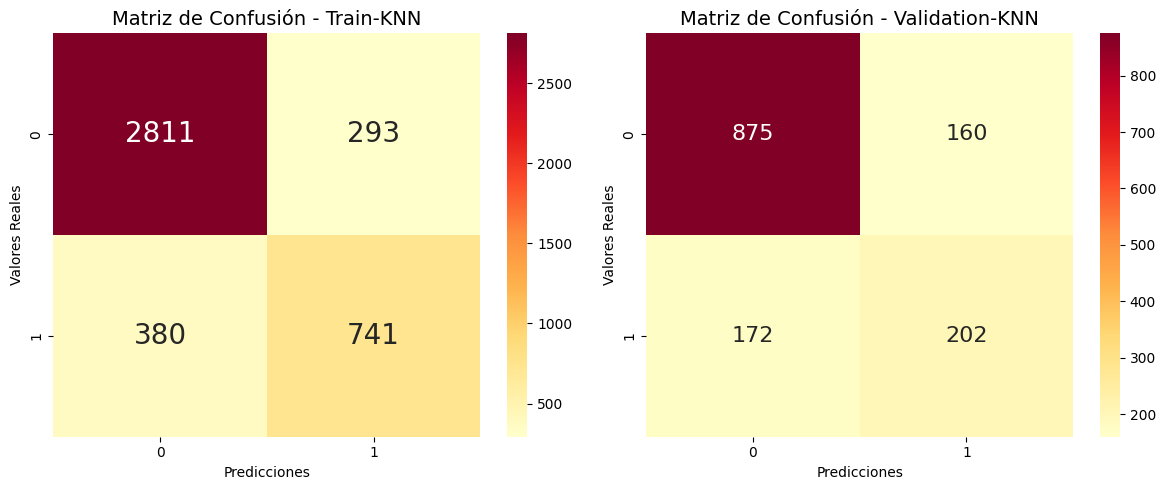

,KNN_train,KNN_validation
accuracy,0.840710,0.764372
recall,0.661017,0.540107
specificity,0.905606,0.845411
precision,0.716634,0.558011
f1,0.687703,0.548913


In [20]:
# Evaluación Modelo Knn
metricas_knn = evaluacion_modelo(modelo_knn, X_train, y_train, X_val, y_val, nombre_modelo = 'KNN', graficar = True)
metricas_knn

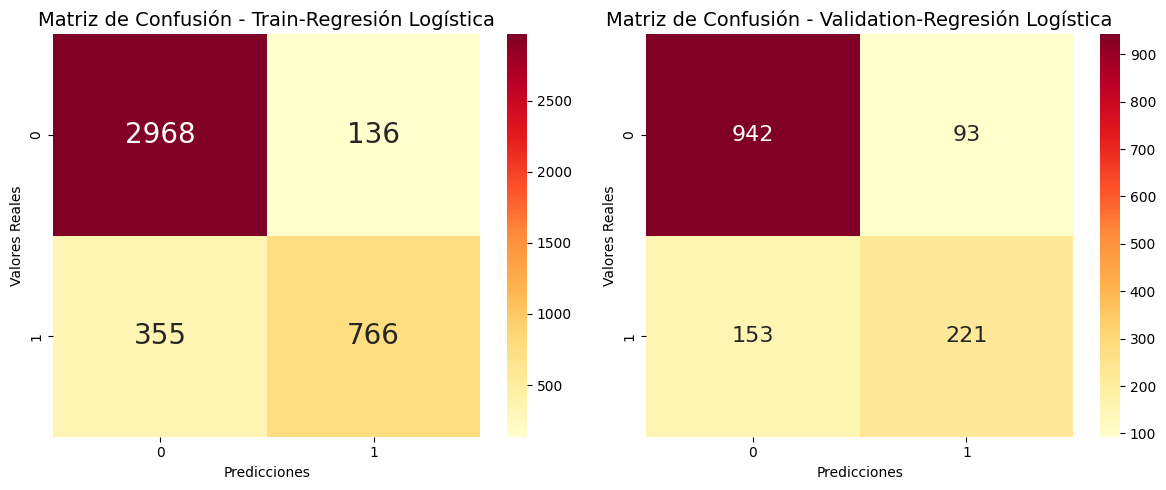

,Regresión Logística_train,Regresión Logística_validation
accuracy,0.883787,0.825408
recall,0.683318,0.590909
specificity,0.956186,0.910145
precision,0.849224,0.703822
f1,0.757291,0.642442


In [21]:
# Evaluación Modelo regresión logistica
metricas_log = evaluacion_modelo(modelo_log, X_train, y_train, X_val, y_val, nombre_modelo = 'Regresión Logística', graficar = True)
metricas_log

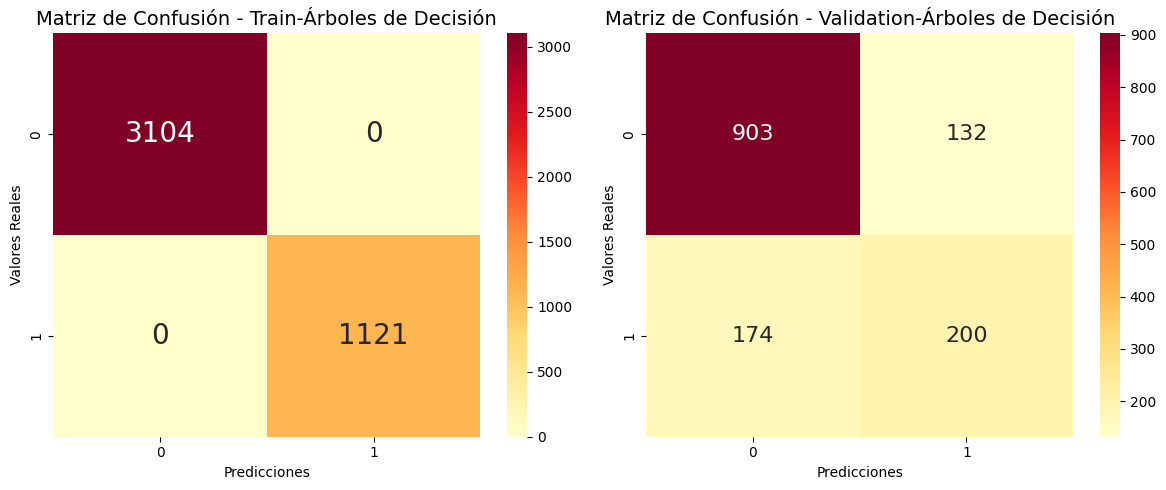

,Árboles de Decisión_train,Árboles de Decisión_validation
accuracy,1.0,0.782825
recall,1.0,0.534759
specificity,1.0,0.872464
precision,1.0,0.602410
f1,1.0,0.566572


In [22]:
#Evaluación modelo ÁRBOLES DE DECISIÓN
metricas_arbol = evaluacion_modelo(modelo_arbol, X_train, y_train, X_val, y_val, nombre_modelo = "Árboles de Decisión", graficar = True)
metricas_arbol

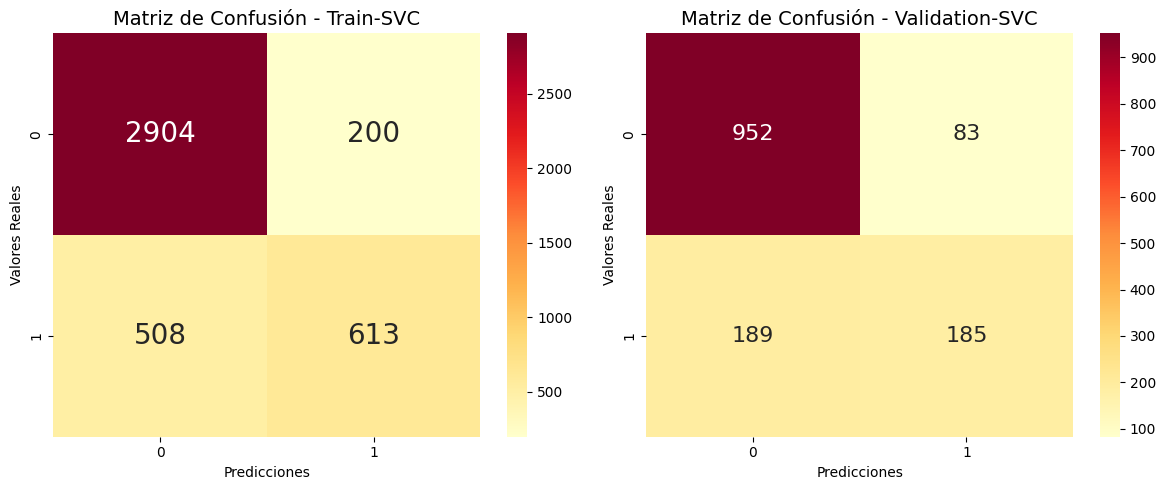

,SVC_train,SVC_validation
accuracy,0.832426,0.806955
recall,0.546833,0.494652
specificity,0.935567,0.919807
precision,0.753998,0.690299
f1,0.633919,0.576324


In [23]:
#Evaluación modelo SVC
metricas_SVC = evaluacion_modelo(modelo_SVC, X_train, y_train, X_val, y_val, nombre_modelo = "SVC", graficar = True)
metricas_SVC


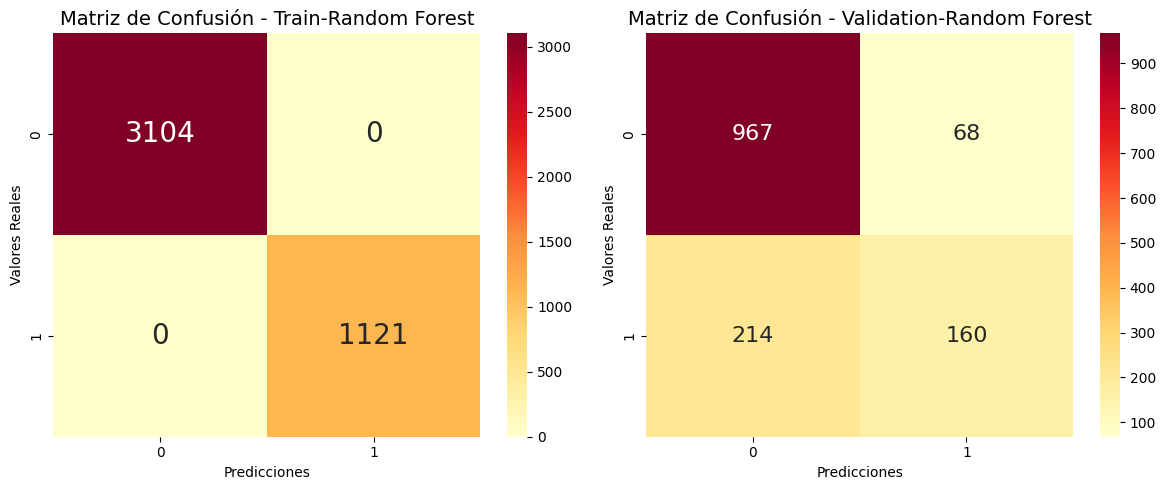

,Random Forest_train,Random Forest_validation
accuracy,1.0,0.799858
recall,1.0,0.427807
specificity,1.0,0.934300
precision,1.0,0.701754
f1,1.0,0.531561


In [24]:
# Evaluación modelo RandomForest
metricas_RF = evaluacion_modelo(modelo_RF, X_train, y_train, X_val, y_val, nombre_modelo = "Random Forest", graficar = True)
metricas_RF

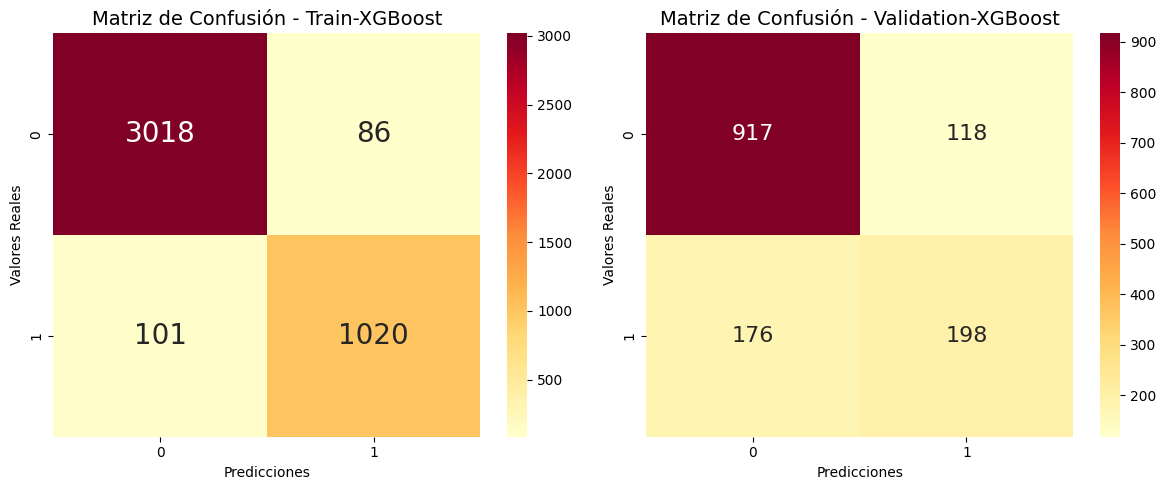

,XGBoost_train,XGBoost_validation
accuracy,0.955740,0.791341
recall,0.909902,0.529412
specificity,0.972294,0.885990
precision,0.922242,0.626582
f1,0.916031,0.573913


In [25]:
#Evaluación modelo XGB
metricas_XGB = evaluacion_modelo(modelo_XGB, X_train, y_train, X_val, y_val, nombre_modelo = "XGBoost", graficar = True)
metricas_XGB

In [26]:
#Metricas Comparación final
metricas_total = pd.concat([metricas_knn, metricas_log, metricas_arbol, metricas_SVC, metricas_RF, metricas_XGB], axis = 1)
metricas_total

,KNN_train,KNN_validation,Regresión Logística_train,Regresión Logística_validation,Árboles de Decisión_train,Árboles de Decisión_validation,SVC_train,SVC_validation,Random Forest_train,Random Forest_validation,XGBoost_train,XGBoost_validation
accuracy,0.840710,0.764372,0.883787,0.825408,1.0,0.782825,0.832426,0.806955,1.0,0.799858,0.955740,0.791341
recall,0.661017,0.540107,0.683318,0.590909,1.0,0.534759,0.546833,0.494652,1.0,0.427807,0.909902,0.529412
specificity,0.905606,0.845411,0.956186,0.910145,1.0,0.872464,0.935567,0.919807,1.0,0.934300,0.972294,0.885990
precision,0.716634,0.558011,0.849224,0.703822,1.0,0.602410,0.753998,0.690299,1.0,0.701754,0.922242,0.626582
f1,0.687703,0.548913,0.757291,0.642442,1.0,0.566572,0.633919,0.576324,1.0,0.531561,0.916031,0.573913


In [ ]:
#Realizamos CURVA ROC y AUC para escoger modelo

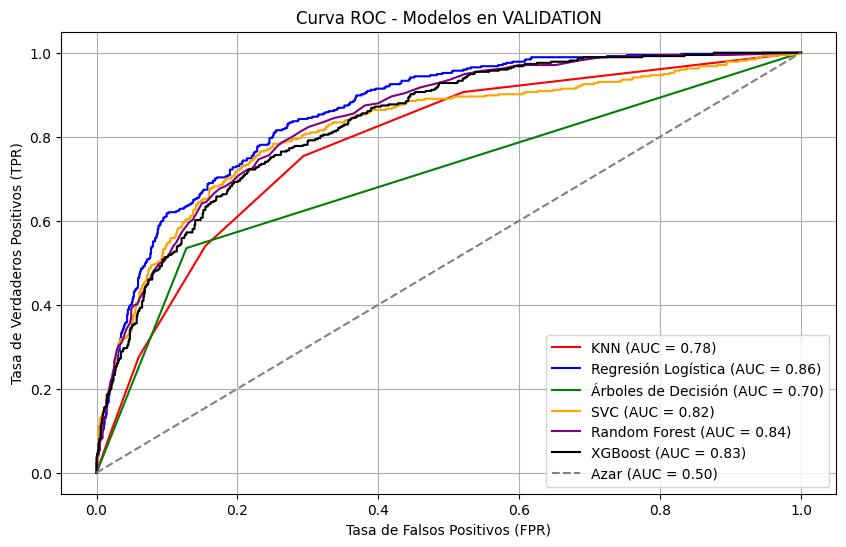

In [27]:
# CÁLCULO DE ROC Y AUC EN VALIDATION

# Curva ROC - Validation
fpr_val_knn, tpr_val_knn, _ = roc_curve(y_val, modelo_knn.predict_proba(X_val)[:, 1])
fpr_val_log, tpr_val_log, _ = roc_curve(y_val, modelo_log.predict_proba(X_val)[:, 1])
fpr_val_arbol, tpr_val_arbol, _ = roc_curve(y_val, modelo_arbol.predict_proba(X_val)[:, 1])
fpr_val_SVC, tpr_val_SVC, _ = roc_curve(y_val, modelo_SVC.predict_proba(X_val)[:, 1])
fpr_val_RF, tpr_val_RF, _ = roc_curve(y_val, modelo_RF.predict_proba(X_val)[:, 1])
fpr_val_XGB, tpr_val_XGB, _ = roc_curve(y_val, modelo_XGB.predict_proba(X_val)[:, 1])

# AUC - Validation
auc_val_knn = roc_auc_score(y_val, modelo_knn.predict_proba(X_val)[:, 1])
auc_val_log = roc_auc_score(y_val, modelo_log.predict_proba(X_val)[:, 1])
auc_val_arbol = roc_auc_score(y_val, modelo_arbol.predict_proba(X_val)[:, 1])
auc_val_SVC = roc_auc_score(y_val, modelo_SVC.predict_proba(X_val)[:, 1])
auc_val_RF = roc_auc_score(y_val, modelo_RF.predict_proba(X_val)[:, 1])
auc_val_XGB = roc_auc_score(y_val, modelo_XGB.predict_proba(X_val)[:, 1])


# GRÁFICA CURVA ROC - VALIDATION
plt.figure(figsize=(10, 6))
plt.plot(fpr_val_knn, tpr_val_knn, color='red', label=f'KNN (AUC = {auc_val_knn:.2f})')
plt.plot(fpr_val_log, tpr_val_log, color='blue', label=f'Regresión Logística (AUC = {auc_val_log:.2f})')
plt.plot(fpr_val_arbol, tpr_val_arbol, color='green', label=f'Árboles de Decisión (AUC = {auc_val_arbol:.2f})')
plt.plot(fpr_val_SVC, tpr_val_SVC, color='orange', label=f'SVC (AUC = {auc_val_SVC:.2f})')
plt.plot(fpr_val_RF, tpr_val_RF, color='purple', label=f'Random Forest (AUC = {auc_val_RF:.2f})')
plt.plot(fpr_val_XGB, tpr_val_XGB, color='black', label=f'XGBoost (AUC = {auc_val_XGB:.2f})')

# Línea diagonal (azar)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Azar (AUC = 0.50)')

# Detalles del gráfico
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC - Modelos en VALIDATION')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [ ]:
#Procedemos a Optimizar el modelo Regresión Logística el cual con sus hiperparametros default
#Ha logrado ser el mejor modelo con mayor AUC, procedemos a optimizar hiperparametros con gridsearchCV

In [28]:
# Pipeline de Regresión Log+istica
pipeline_log = Pipeline(steps=[
    ('preprocessor', preprocessor_1),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
])

# Grid de parámetros

param_grid_log = {
    'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],  # Regularización
    'classifier__penalty': ['l1', 'l2'],               # Tipo de regularización
    'classifier__solver': ['liblinear', 'saga'],        # Algoritmos que soportan l1/l2
}

# GridSearch con CV sobre X_train

grid_log = GridSearchCV(
    pipeline_log,
    param_grid_log,
    cv=5,                      # Validación cruzada de 5 folds
    scoring='roc_auc',         # Maximiza el AUC
    n_jobs=-1,
    verbose=1
)

#Entrenar el modelo obtenido arriba
g_res = grid_log.fit(X_train, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


In [30]:
# el mejor accuracy
print("Mejor score promedio 5 CV: ", g_res.best_score_)
# Los mejores hiperparametros
print("Mejores hiperparametros", g_res.best_params_)
# el mejor modelo
modelo_log_optimo = g_res.best_estimator_

Mejor score promedio 5 CV:  0.8449171740614588
Mejores hiperparametros {'classifier__C': 1, 'classifier__penalty': 'l1', 'classifier__solver': 'saga'}


In [31]:
#POR ULTIMO EVALUAMOS EN TEST EL MODELO OPTIMIZADO
#1. Usamos modelo entrenado para predecir test
y_pred_proba_test = modelo_log_optimo.predict_proba(X_test)[:, 1]
#2. Calculamos curva ROC y AUC con los resultados de test
fpr_test, tpr_test, _ = roc_curve(y_test, y_pred_proba_test)
auc_test = roc_auc_score(y_test, y_pred_proba_test)
#Resultados
print(f"AUC FINAL en TEST: {auc_test:.4f}")

AUC FINAL en TEST: 0.8326


In [ ]:
#Realizaré Optimización de Hiperparametros para XGBoost para compararlo finalmente con RegLog

In [35]:
# Pipeline de XGBoost
pipeline_xgb = Pipeline(steps=[
    ('preprocessor', preprocessor_2),
    ('classifier', XGBClassifier(
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss'
    ))
])

# Grid de parámetros (reducido para que sea rápido)
param_grid_xgb = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [3, 5],
    'classifier__learning_rate': [0.01, 0.1],
    'classifier__subsample': [0.8, 1.0],
    'classifier__colsample_bytree': [0.8, 1.0],
    'classifier__reg_alpha': [0, 0.1],
    'classifier__reg_lambda': [0.5, 1]
}

# GridSearch
grid_xgb = GridSearchCV(
    pipeline_xgb,
    param_grid_xgb,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

g_res_xgb = grid_xgb.fit(X_train, y_train)

# Resultados
print(f"Mejor score: {g_res_xgb.best_score_:.4f}")
print(f"Mejores parámetros: {g_res_xgb.best_params_}")

Fitting 5 folds for each of 128 candidates, totalling 640 fits
Mejor score: 0.8474
Mejores parámetros: {'classifier__colsample_bytree': 0.8, 'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 100, 'classifier__reg_alpha': 0.1, 'classifier__reg_lambda': 1, 'classifier__subsample': 1.0}


In [ ]:
#Ahora nos aseguramos de no perder rendimiento, re entrenando XGBoost con EarlyStopping

In [38]:
#POR ULTIMO EVALUAMOS EN TEST EL MODELO OPTIMIZADO
modelo_xgb_optimo = g_res_xgb.best_estimator_
#1. Usamos modelo entrenado para predecir test
y_pred_proba_test_xgb = modelo_xgb_optimo.predict_proba(X_test)[:, 1]
#2. Calculamos curva ROC y AUC con los resultados de test
fpr_test_xgb, tpr_test_xgb, _ = roc_curve(y_test, y_pred_proba_test_xgb)
auc_test_xgb = roc_auc_score(y_test, y_pred_proba_test_xgb)
#Resultados
print(f"AUC FINAL en TEST: {auc_test_xgb:.4f}")

AUC FINAL en TEST: 0.8350


In [39]:
#EN RESUMEN EL MEJOR MODELO DE LOS QUE HE PROBADO HA SIDO LOGREG AL SER MÁS SIMPLE, RÁPIDO E INTERPRETABLE